In [227]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline

In [228]:
df_orig = pd.read_csv("https://raw.githubusercontent.com/alexeygrigorev/datasets/master/AB_NYC_2019.csv")

df= df_orig

In [229]:
col_names = df.columns.tolist()
print("Column names:")
print(col_names,'\n')

print('Data dimensions:',df.shape,'\n')

print("Sample data:")
df.head(3)

Column names:
['id', 'name', 'host_id', 'host_name', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365'] 

Data dimensions: (48895, 16) 

Sample data:


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365


In [230]:
df= df[[
    'latitude',
    'longitude',
    'price',
    'minimum_nights',
    'number_of_reviews',
    'reviews_per_month',
    'calculated_host_listings_count',
    'availability_365'
]]


In [231]:
df.head()

,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,40.64749,-73.97237,149,1,9,0.21,6,365
1,40.75362,-73.98377,225,1,45,0.38,2,355
2,40.80902,-73.94190,150,3,0,NaN,1,365
3,40.68514,-73.95976,89,1,270,4.64,1,194
4,40.79851,-73.94399,80,10,9,0.10,1,0


# Question 1

Find a feature with missing values. How many missing values does it have?

In [232]:
df.isnull().sum()

latitude                              0
longitude                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

# Question 2

What's the median (50% percentile) for variable 'minimum_nights'?

In [233]:
df["minimum_nights"].median()

3.0

## Split the data

* Shuffle the initial dataset, use seed 42.
* Split your data in train/val/test sets, with 60%/20%/20% distribution.
* Make sure that the target value ('price') is not in your dataframe.
* Apply the log transformation to the price variable using the np.log1p()     function.


In [234]:
np.random.seed(42)

n = len(df)

n_val = int(0.2 * n)
n_test = int(0.2 * n)
n_train = n - (n_val + n_test)

idx = np.arange(n)
np.random.shuffle(idx)

df_shuffled = df.iloc[idx]

df_train = df_shuffled.iloc[:n_train].copy()
df_val = df_shuffled.iloc[n_train:n_train+n_val].copy()
df_test = df_shuffled.iloc[n_train+n_val:].copy()


y_train_orig = df_train.price.values
y_val_orig = df_val.price.values
y_test_orig = df_test.price.values

y_train = np.log1p(df_train.price.values)
y_val = np.log1p(df_val.price.values)
y_test = np.log1p(df_test.price.values)

del df_train['price']
del df_val['price']
del df_test['price']


# Question 3

* We need to deal with missing values for the column from Q1.
* We have two options: fill it with 0 or with the mean of this variable.
* Try both options. For each, train a linear regression model without regularization using the code from the lessons.
* For computing the mean, use the training only!
* Use the validation dataset to evaluate the models and compare the RMSE of each option.
* Round the RMSE scores to 2 decimal digits using round(score, 2)
* Which option gives better RMSE?


## Linear Regression 

In [235]:
def train_linear_regression(X,y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones,X])
    
    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)
    
    return w[0], w[1:]

## df preparation

In [236]:
def prepare_X_fillna_zero(df):    
    df = df.fillna(0)
    X = df.values
    return X

In [237]:
def prepare_X_fillna_mean(df):
    df = df.fillna(0)
    X = df.values
    return X

## Lineer regression/ filled nulls with zero 

In [238]:
X_train = prepare_X_fillna_zero(df_train)
w_0, w = train_linear_regression(X_train, y_train)

In [239]:
y_pred = w_0 + X_train.dot(w)

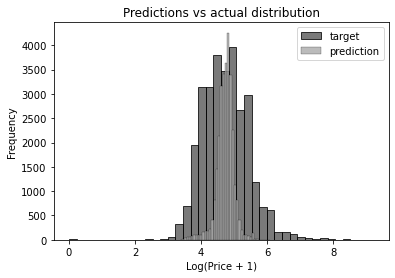

In [240]:
plt.figure(figsize=(6, 4))

sns.histplot(y_train, label='target', color='#222222', alpha=0.6, bins=40)
sns.histplot(y_pred, label='prediction', color='#aaaaaa', alpha=0.8, bins=40)

plt.legend()

plt.ylabel('Frequency')
plt.xlabel('Log(Price + 1)')
plt.title('Predictions vs actual distribution')

plt.show()

In [241]:
def rmse(y, y_pred):
    error = y_pred - y
    mse = (error ** 2).mean()
    return np.sqrt(mse)

In [242]:
rmse(y_train, y_pred).round(2)

0.64

In [243]:
X_val = prepare_X_fillna_zero(df_val)
y_pred = w_0 + X_val.dot(w)

In [244]:
rmse(y_val, y_pred).round(2)

0.64

# Question 4


* Now let's train a regularized linear regression.
* For this question, fill the NAs with 0.
* Try different values of r from this list: [0, 0.000001, 0.0001, 0.001, 0.01, 0.1, 1, 5, 10].
* Use RMSE to evaluate the model on the validation dataset.
* Round the RMSE scores to 2 decimal digits.
* Which r gives the best RMSE?

* If there are multiple options, select the smallest r.

## Regularization 

In [245]:
def train_linear_regression_reg(X, y, r=0.0):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    reg = r * np.eye(XTX.shape[0])
    XTX = XTX + reg

    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)
    
    return w[0], w[1:]

In [246]:
X_train = prepare_X_fillna_zero(df_train)

In [247]:
for r in [0, 0.000001, 0.0001, 0.001, 0.01, 0.1, 1, 5, 10]:
    w_0, w = train_linear_regression_reg(X_train, y_train, r=r)
    print('%5s, %.2f, %.2f, %.2f' % (r, w_0, w[3], w[6]))

    0, -419.91, -0.00, 0.00
1e-06, -419.86, -0.00, 0.00
0.0001, -414.98, -0.00, 0.00
0.001, -375.27, -0.00, 0.00
 0.01, -191.78, -0.00, 0.00
  0.1, -32.56, -0.00, 0.00
    1, -3.50, -0.00, 0.00
    5, -0.70, -0.00, 0.00
   10, -0.35, -0.00, 0.00


In [248]:
X_train = prepare_X_fillna_zero(df_train)
w_0, w = train_linear_regression_reg(X_train, y_train, r=0)

y_pred = w_0 + X_train.dot(w)
print('train', rmse(y_train, y_pred).round(2))

X_val = prepare_X_fillna_zero(df_val)
y_pred = w_0 + X_val.dot(w)
print('val', rmse(y_val, y_pred).round(2))

train 0.64
val 0.64


In [249]:
X_train = prepare_X_fillna_zero(df_train)
w_0, w = train_linear_regression_reg(X_train, y_train, r=0.1)

y_pred = w_0 + X_train.dot(w)
print('train', rmse(y_train, y_pred))

X_val = prepare_X_fillna_zero(df_val)
y_pred = w_0 + X_val.dot(w)
print('val', rmse(y_val, y_pred))

train 0.675503105966671
val 0.6773299642429449


In [250]:
X_train = prepare_X_fillna_zero(df_train)
X_val = prepare_X_fillna_zero(df_val)

for r in [0, 0.000001, 0.0001, 0.001, 0.01, 0.1, 1, 5, 10]:
    w_0, w = train_linear_regression_reg(X_train, y_train, r=r)
    y_pred = w_0 + X_val.dot(w)
    print('%6s' %r, rmse(y_val, y_pred).round(2))

     0 0.64
 1e-06 0.64
0.0001 0.64
 0.001 0.64
  0.01 0.66
   0.1 0.68
     1 0.68
     5 0.68
    10 0.68


In [251]:
X_train = prepare_X_fillna_zero(df_train)
w_0, w = train_linear_regression_reg(X_train, y_train, r=0)

y_pred = w_0 + X_train.dot(w)
print('train', rmse(y_train, y_pred).round(2))

X_val = prepare_X_fillna_zero(df_val)
y_pred = w_0 + X_val.dot(w)
print('validation', rmse(y_val, y_pred).round(2))

train 0.64
validation 0.64


# Question 5

* We used seed 42 for splitting the data. Let's find out how selecting the seed influences our score.
* Try different seed values: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9].
* For each seed, do the train/validation/test split with 60%/20%/20% distribution.
* Fill the missing values with 0 and train a model without regularization.
* For each seed, evaluate the model on the validation dataset and collect the RMSE scores.
* What's the standard deviation of all the scores? To compute the standard deviation, use np.std.
* Round the result to 3 decimal digits (round(std, 3))

* Note: Standard deviation shows how different the values are. If it's low, then all values are approximately the same. If it's high, the values are different. If standard deviation of scores is low, then our model is stable.


In [276]:
def different_seeds (seed, df):
    np.random.seed(seed)

    n = len(df)

    n_val = int(0.2 * n)
    n_test = int(0.2 * n)
    n_train = n - (n_val + n_test)

    idx = np.arange(n)
    np.random.shuffle(idx)

    df_shuffled = df.iloc[idx]

    df_train = df_shuffled.iloc[:n_train].copy()
    df_val = df_shuffled.iloc[n_train:n_train+n_val].copy()
    df_test = df_shuffled.iloc[n_train+n_val:].copy()


    y_train_orig = df_train.price.values
    y_val_orig = df_val.price.values
    y_test_orig = df_test.price.values

    y_train = np.log1p(df_train.price.values)
    y_val = np.log1p(df_val.price.values)
    y_test = np.log1p(df_test.price.values)
    
    

    del df_train['price']
    del df_val['price']
    del df_test['price']
    
    X_train =  prepare_X_fillna_mean(df_train)
    X_val  = prepare_X_fillna_zero(df_val)
    X_test = prepare_X_fillna_zero(df_test)
    
  
    for r in [0, 0.000001, 0.0001, 0.001, 0.01, 0.1, 1, 5, 10]:
        w_0, w = train_linear_regression_reg(X_train, y_train, r=r)
        y_pred = w_0 + X_val.dot(w)
        print('%6s' %r, rmse(y_val, y_pred).round(2))
        
        
        
   
        
    
    
    
 

In [277]:
for i in [0,1,2,3,4,5,6,7,8,9]  :
    print("\n")
    different_seeds(i,df)



     0 0.65
 1e-06 0.65
0.0001 0.65
 0.001 0.66
  0.01 0.67
   0.1 0.69
     1 0.69
     5 0.69
    10 0.69


     0 0.65
 1e-06 0.65
0.0001 0.65
 0.001 0.65
  0.01 0.66
   0.1 0.68
     1 0.69
     5 0.69
    10 0.69


     0 0.65
 1e-06 0.65
0.0001 0.65
 0.001 0.65
  0.01 0.66
   0.1 0.68
     1 0.68
     5 0.68
    10 0.68


     0 0.64
 1e-06 0.64
0.0001 0.64
 0.001 0.64
  0.01 0.65
   0.1 0.67
     1 0.68
     5 0.68
    10 0.68


     0 0.64
 1e-06 0.64
0.0001 0.64
 0.001 0.65
  0.01 0.66
   0.1 0.68
     1 0.68
     5 0.68
    10 0.68


     0 0.63
 1e-06 0.63
0.0001 0.63
 0.001 0.63
  0.01 0.64
   0.1 0.66
     1 0.67
     5 0.67
    10 0.67


     0 0.63
 1e-06 0.63
0.0001 0.63
 0.001 0.63
  0.01 0.64
   0.1 0.66
     1 0.67
     5 0.67
    10 0.67


     0 0.65
 1e-06 0.65
0.0001 0.65
 0.001 0.65
  0.01 0.66
   0.1 0.68
     1 0.69
     5 0.69
    10 0.69


     0 0.65
 1e-06 0.65
0.0001 0.65
 0.001 0.65
  0.01 0.66
   0.1 0.68
     1 0.69
     5 0.69
    10 0.69


     0 0